In [2]:
import pandas as pd 
# Load theCSV file from the data folder
# We use sep=';' because the CSV file uses semicolons as delimiters
df = pd.read_csv('../data/raw/data.csv', sep=';')
# Print dataset shape 
print(f"Dataset Shape: {df.shape}")

# Print the first 5 rows 
df.head()



Dataset Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# Strip any hidden whitespaces, tabs \t or newlines from all column names 
df.columns = df.columns.str.strip()

print("cleaned column names:")
df.columns.tolist()

cleaned column names:


['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rat

In [4]:
# Get data types for each column 
data_types = df.dtypes

# Get missing values count per column
missing_count = df.isnull().sum()

# Calculate missing values percentage per column
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Combine them into a single summary DataFrame fpr readability 
data_quality_df = pd.DataFrame({
    'Data Type' : data_types,
    'Missing Count' : missing_count,
    'Missing percentage (%)' : missing_percentages.round(2)
})

data_quality_df

,Data Type,Missing Count,Missing percentage (%)
Marital status,int64,0,0.0
Application mode,int64,0,0.0
Application order,int64,0,0.0
Course,int64,0,0.0
Daytime/evening attendance,int64,0,0.0
Previous qualification,int64,0,0.0
Previous qualification (grade),float64,0,0.0
Nacionality,int64,0,0.0
Mother's qualification,int64,0,0.0
Father's qualification,int64,0,0.0


Matplotlib is building the font cache; this may take a moment.


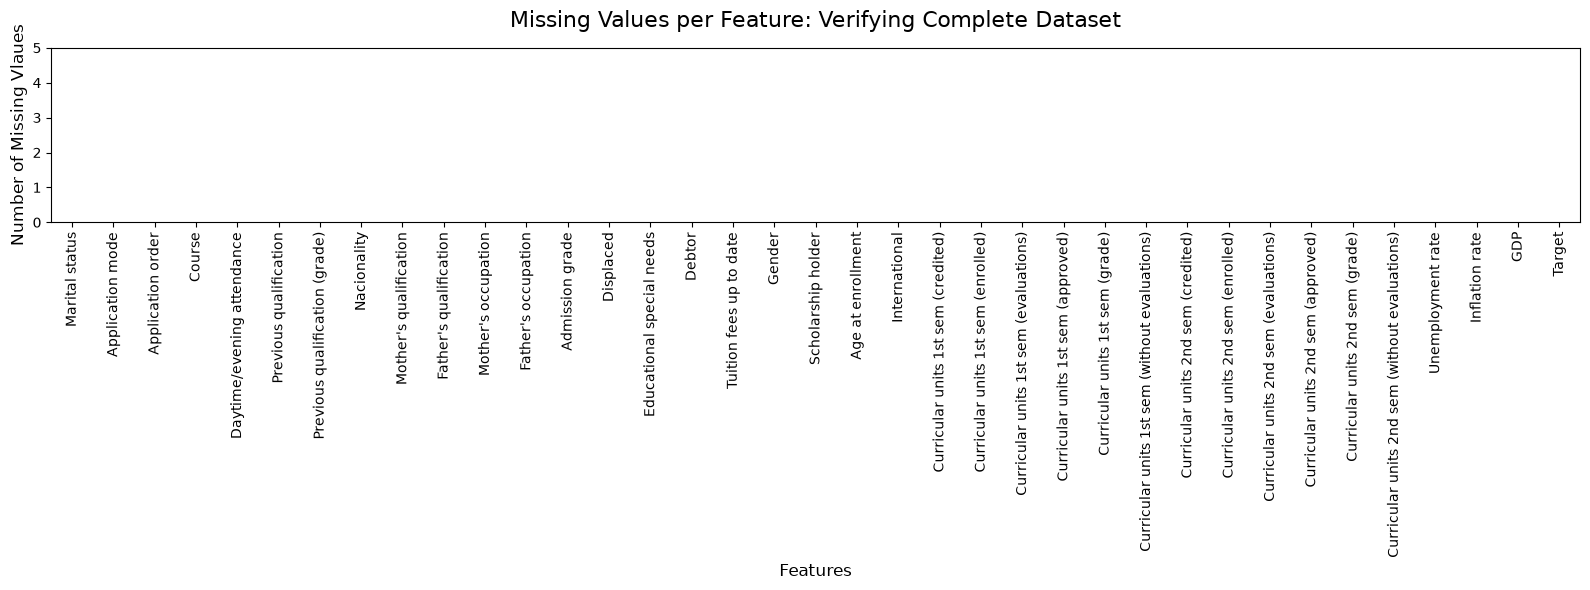

Bar chart saved successfully


In [ ]:
# Visual plot
import matplotlib.pyplot as plt
import seaborn as sns 

# Extract missing values counts 
missing_counts = df.isnull().sum()

# wide figure to fit all 37 clomuns 
plt.figure(figsize=(16, 6))

# Create a bar chart 
sns.barplot(x=missing_counts.index, y=missing_counts.values, color='steelblue')

# Add titles 
plt.title('Missing Values per Feature: Verifying Complete Dataset', fontsize=16, pad=15)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Number of Missing Values', fontsize=12)

# Rotation of X axis labels so they don't overlap 
plt.xticks(rotation=90)

# Force the Y axis to have a small range because all our values are 0 Matplotlib made the Y axis look strange
plt.ylim(0, 5)

# Labels are tight so the rotated labels, dont get chopped off 
plt.tight_layout()

# Save the figure
plt.savefig('../outputs/figures/missing_values_bar.png', dpi=300, bbox_inches='tight')

# Display 
plt.show()

print("Bar chart saved successfully")

In [8]:
# Target Variable 

# Get the absolute count for each class
class_counts = df['Target'].value_counts()

# Get the percentage of each class 
#normalize=TRUE calculates the proportion 0 to 1 so we multiply by 100 for percentage
class_percentages = df['Target'].value_counts(normalize=True) * 100

# Combine into a clean Pandas DataFrame
class_distribution_df = pd.DataFrame({
    'Count' : class_counts,
    'Percentage (%)' : class_percentages.round(2) 
})
# Add a name for index so the table has a clear header for the classes 
class_distribution_df.index.name = 'Student Status'

class_distribution_df

,Count,Percentage (%)
Student Status,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


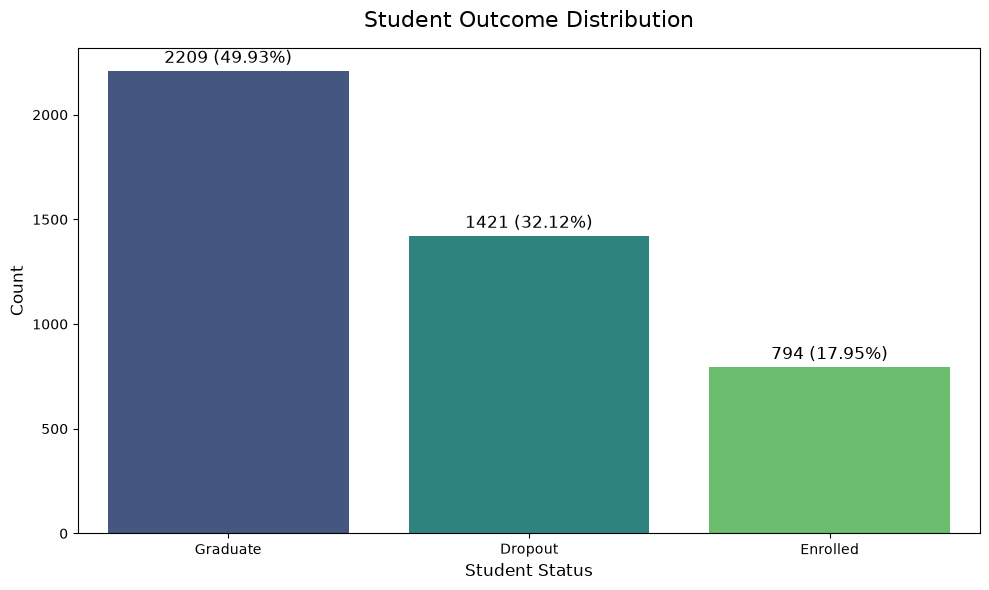

Bar chart saved successfully


In [13]:

# Visual Plot 
import matplotlib.pyplot as plt
import seaborn as sns 

# Get the absolute count for each class
class_counts = df['Target'].value_counts()
total_students = len(df)

# Set up the figure size 
plt.figure(figsize=(10, 6))

# Create the bar chart 
ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette='viridis',
    legend=False
)
# 'hue=class_counts.index' and 'palette='viridis' ensures each bar gets a different colour

# Add count labels directly on top of each bar 
for container in ax.containers:
    custom_labels =[f'{int(bar.get_height())} ({(bar.get_height() / total_students) * 100:.2f}%)' for bar in container]
    ax.bar_label(container, labels=custom_labels, padding=3, fontsize=12)

# Add titles 
plt.title('Student Outcome Distribution', fontsize=16, pad=15)
plt.xlabel('Student Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Labels are tight so the rotated labels, dont get chopped off 
plt.tight_layout()

# Save the figure
plt.savefig('../outputs/figures/Student_Outcome_Distribution.png', dpi=300, bbox_inches='tight')

# Display 
plt.show()

print("Bar chart saved successfully")

Mapping Dataset for later visuals,

In [5]:
df_visualisation = df.copy()

# Applying mappings for the binary features
df_visualisation['Gender'] = df_visualisation['Gender'].map({0: 'Female', 1:'Male'})
df_visualisation['Daytime/evening attendance'] = df_visualisation['Daytime/evening attendance'].map({0: 'Evening', 1: 'Daytime'})
df_visualisation['Displaced'] = df_visualisation['Displaced'].map({0: 'No', 1:'Yes'})
df_visualisation['International'] = df_visualisation['International'].map({0: 'No', 1:'Yes'})
df_visualisation['Scholarship holder'] = df_visualisation['Scholarship holder'].map({0: 'No', 1:'Yes'})
df_visualisation['Debtor'] = df_visualisation['Debtor'].map({0: 'No', 1:'Yes'})
df_visualisation['Tuition fees up to date'] = df_visualisation['Tuition fees up to date'].map({0: 'Not Up To Date', 1:'Up To Date'})
df_visualisation['Educational special needs'] = df_visualisation['Educational special needs'].map({0: 'No', 1:'Yes'})

# Save the mapped dataset to have a hard copy
df_visualisation.to_csv('../data/processed/df_visualisation_mapped.csv', index=False)

print("Mapping Applied Correctly")
print(df_visualisation[['Gender', 'Daytime/evening attendance', 'Scholarship holder', 'Tuition fees up to date']].head())
print("\nFile saved to '../data/processed/")

Mapping Applied Correctly
   Gender Daytime/evening attendance Scholarship holder  \
0    Male                    Daytime                 No   
1    Male                    Daytime                 No   
2    Male                    Daytime                 No   
3  Female                    Daytime                 No   
4  Female                    Evening                 No   

  Tuition fees up to date  
0              Up To Date  
1          Not Up To Date  
2          Not Up To Date  
3              Up To Date  
4              Up To Date  

File saved to '../data/processed/


In [31]:
# Define the mapping dictionary for all 17 courses 
course_map = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)'
}

# Apply the mapping to the 'Course' column
df_visualisation['Course'] = df_visualisation['Course'].map(course_map)

# Re save the dataset 
df_visualisation.to_csv('../data/processed/df_visualisation_mapped.csv', index=False)

print("Course mapping applied successfully")
print(df_visualisation[['Course', 'Target']].head())

Course mapping applied successfully
                                Course    Target
0      Animation and Multimedia Design   Dropout
1                              Tourism  Graduate
2                 Communication Design   Dropout
3         Journalism and Communication  Graduate
4  Social Service (evening attendance)  Graduate


In [ ]:
# Define the mapping dictionary for Marital Status
marital_map = {
    1: 'Single',
    2: 'Married',
    3: 'Widower',
    4: 'Divorced',
    5: 'Facto Union',
    6: 'Legally Separated'
}
# Apply the mapping to the 'Marital Status' column
df_visualisation['Marital status'] = df_visualisation['Marital status'].map(marital_map)

# Re save the dataset 
df_visualisation.to_csv('../data/processed/df_visualisation_mapped.csv', index=False)

print("Marital Status mapping applied successfully")
print(df_visualisation[['Marital status', 'Target']].head())


Marital Status mapping applied successfully
  Marital status    Target
0         Single   Dropout
1         Single  Graduate
2         Single   Dropout
3         Single  Graduate
4        Married  Graduate


Binary target preparation on original df

In [33]:
# Extract and save the 'Enrolled' students separately
df_enrolled = df[df['Target'] == 'Enrolled'].copy()

# Save them to processed folder so they are safe for later stage 
df_enrolled.to_csv('../data/processed/enrolled_students.csv', index=False)

# Keep only 'Graduate' and 'Dropout' in the main dataframe
df = df[df['Target'].isin(['Graduate', 'Dropout'])].copy()

# Create the binary target column 
df['Target'] = df['Target'].map({'Graduate': 0, 'Dropout': 1})

# Confirm new shape
print(f"--- Shape Confirmation ---")
print(f"Modelling Dataset shape: {df.shape[0]}rows, {df.shape[1]} columns")
print(f"Enrolled Students Set Aside: {df_enrolled.shape[0]} rows\n")

# Confirm new class distribution
print(f"--- New Class Distribution ---")
class_counts = df['Target'].value_counts()
class_percentages = (df['Target'].value_counts(normalize=True) * 100).round(2)

# Display as a readable output 
for target_val, count in class_counts.items():
    label = "Dropout" if target_val == 1 else "Graduate"
    percentage = class_percentages[target_val]
    print(f"{label} (class {target_val}): {count} students ({percentage}%)")


--- Shape Confirmation ---
Modelling Dataset shape: 3630rows, 37 columns
Enrolled Students Set Aside: 794 rows

--- New Class Distribution ---
Graduate (class 0): 2209 students (60.85%)
Dropout (class 1): 1421 students (39.15%)


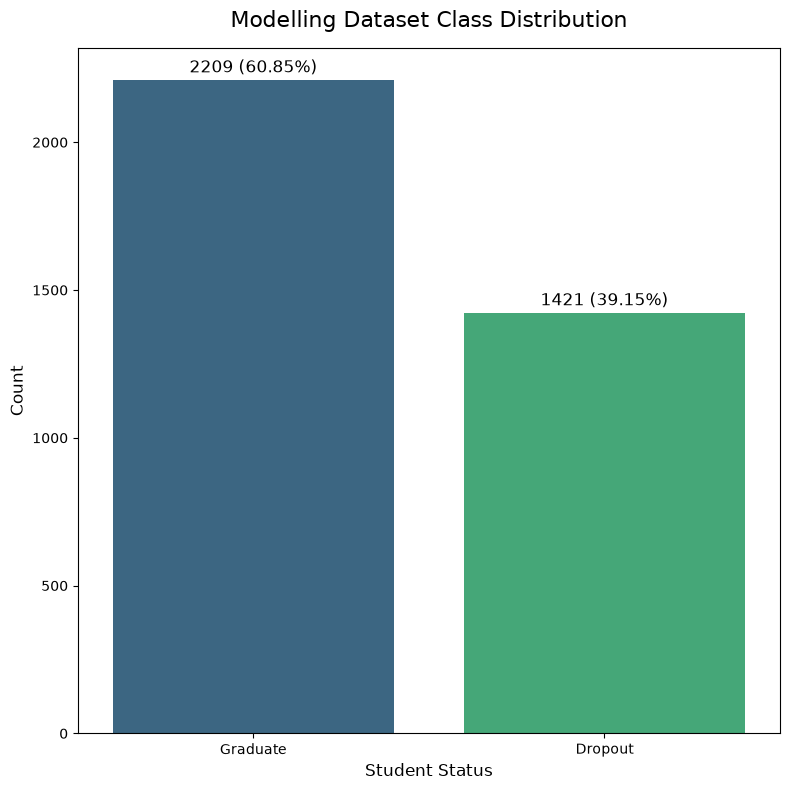

Bar chart saved successfully


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns 

# Get the new counts and total for percentages
class_counts = df['Target'].value_counts()
total_students = df.shape[0]

# Figure size
plt.figure(figsize=(8, 8))

# Creating bar chart 
ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette='viridis',
    legend=False
)

# add custom labels 
for container in ax.containers:
    custom_labels = [f'{int(bar.get_height())} ({(bar.get_height() / total_students) * 100:.2f}%)' for bar in container]
    ax.bar_label(container, labels=custom_labels, padding=3, fontsize=12)

# Titles
plt.title('Modelling Dataset Class Distribution', fontsize=16, pad=15)
plt.xlabel('Student Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Costomising x axis to show readable ladels instead of 0 and 1  these will go in order graduate first and than dropout
plt.xticks(ticks=[0, 1], labels=['Graduate', 'Dropout'])

plt.tight_layout()

plt.savefig('../outputs/figures/Modelling_Class_Distribution.png', dpi=300, bbox_inches='tight')

plt.show()

print("Bar chart saved successfully")

In [35]:
# Save the main Graduate/Dropout daraframe to your hard drive 
df.to_csv('../data/processed/modelling_data_master.csv', index=False)

print("Master modelling dataset securely saved")

Master modelling dataset securely saved


In [36]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Target distribution:")
print(df['Target'].value_counts())

Shape: 3630 rows, 37 columns
Target distribution:
Target
0    2209
1    1421
Name: count, dtype: int64


Defining features 

In [37]:
# Define enrollement features, there are 24 
enrollment_features = [
    'Marital status', 'Nacionality', 'Gender', 'Age at enrollment',
    'Displaced', 'International', "Mother's qualification",
    "Father's qualification", "Mother's occupation", "Father's occupation",
    'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Scholarship holder', 'Unemployment rate', 'Inflation rate', 'GDP',
    'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification',
    'Previous qualification (grade)', 'Admission grade'
]

# Define semester 1 features, there are 6 
semester1_features = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)'
]

# Combine into one list of 30 features
features_to_keep = enrollment_features + semester1_features

# Create X with the 30 feature clomuns which will be the predictors
X = df[features_to_keep].copy()

# Create y with just the Target column which will be the output 
y = df['Target'].copy()

# Print shapes to confirm everything worked fine 
print("--- Data Split Confirmation ---")
print(f"X (Features) Shape: {X.shape[0]} rows, {X.shape[1]} columns")
print(f"y (Target) Shape: {y.shape[0]} rows\n")

# Save X and y to processed folder 

X.to_csv('../data/processed/X_features.csv', index=False)
y.to_csv('../data/processed/y_target.csv', index=False)

print("X and y are securely saved to your hard drive")

--- Data Split Confirmation ---
X (Features) Shape: 3630 rows, 30 columns
y (Target) Shape: 3630 rows

X and y are securely saved to your hard drive


Visualisations

Correlation Heatmap on numerical only

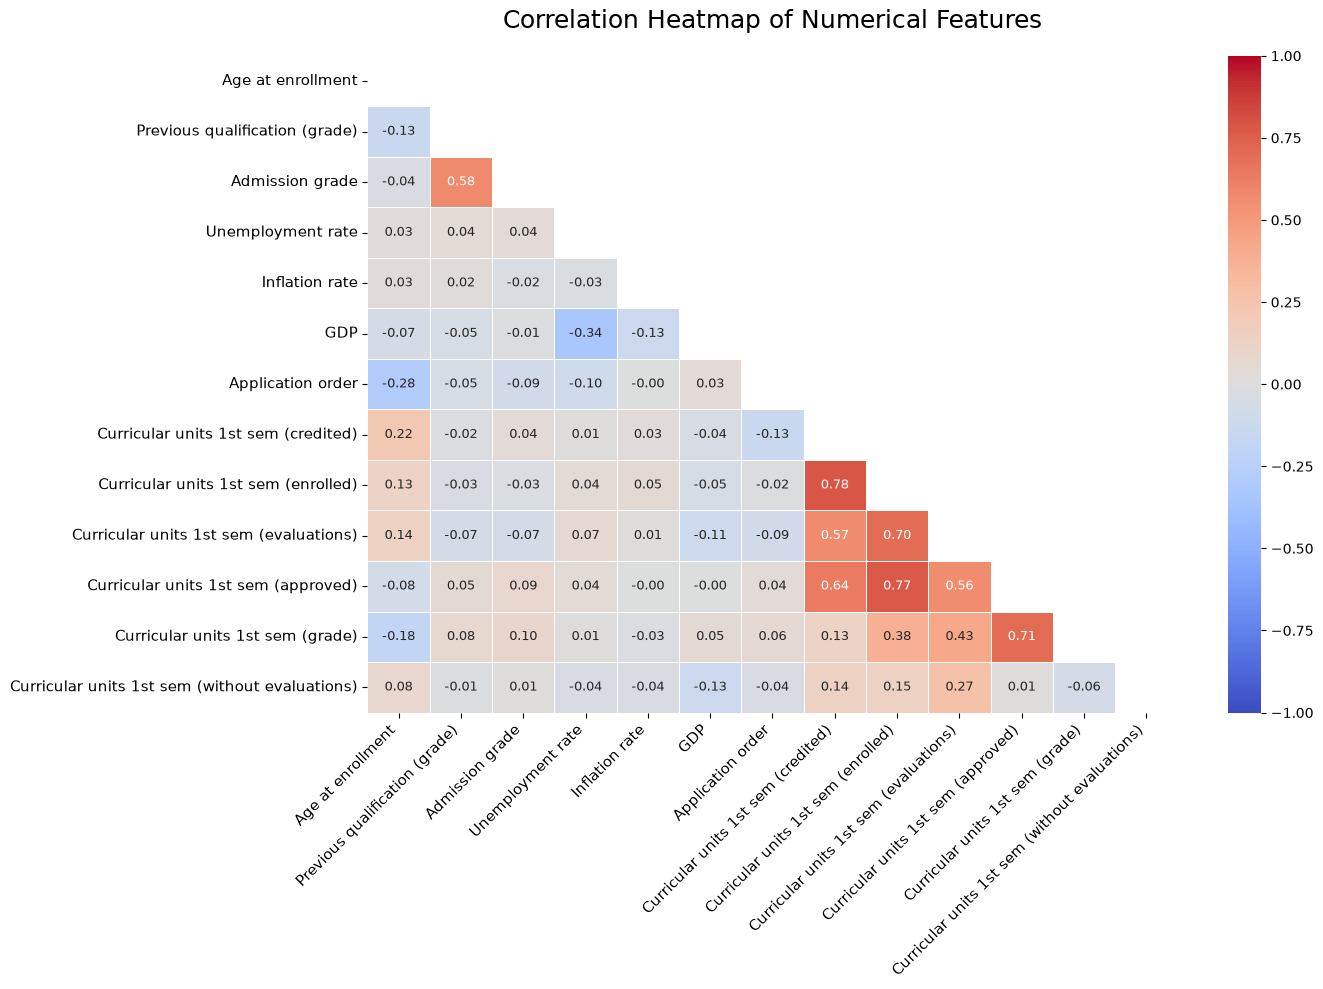

Heatmap successfully generated


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

# Select numerical only from X 
numerical_cols = [
    'Age at enrollment',
    'Previous qualification (grade)',
    'Admission grade',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
    'Application order',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)'
]
X_num = X[numerical_cols]

# Calculate the correlation matrix 
corr_matrix = X_num.corr()

# plot the heatmap 
plt.figure(figsize=(14, 10))

# Create a mask to hide the upper triangle - removes the duplicate information
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap 
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, # Prints the exact correlation numbers inside the boxes
    fmt=".2f", # Rounds the numer to 2 decimal places
    cmap='coolwarm', # Blue for negative correlation, red for positive 
    vmin=-1, vmax=1, # Sets the scale from -1 to 1 
    linewidths=0.5, # Adds a small gridline between boxes for readability 
    annot_kws={"size": 9} # Slightly smaller text to fit the boxes perfectly 
)

# Apply Titles
plt.title("Correlation Heatmap of Numerical Features", fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()

plt.savefig('../outputs/figures/Numerical_Correlation_Heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

print("Heatmap successfully generated")

Dropout rate by Course

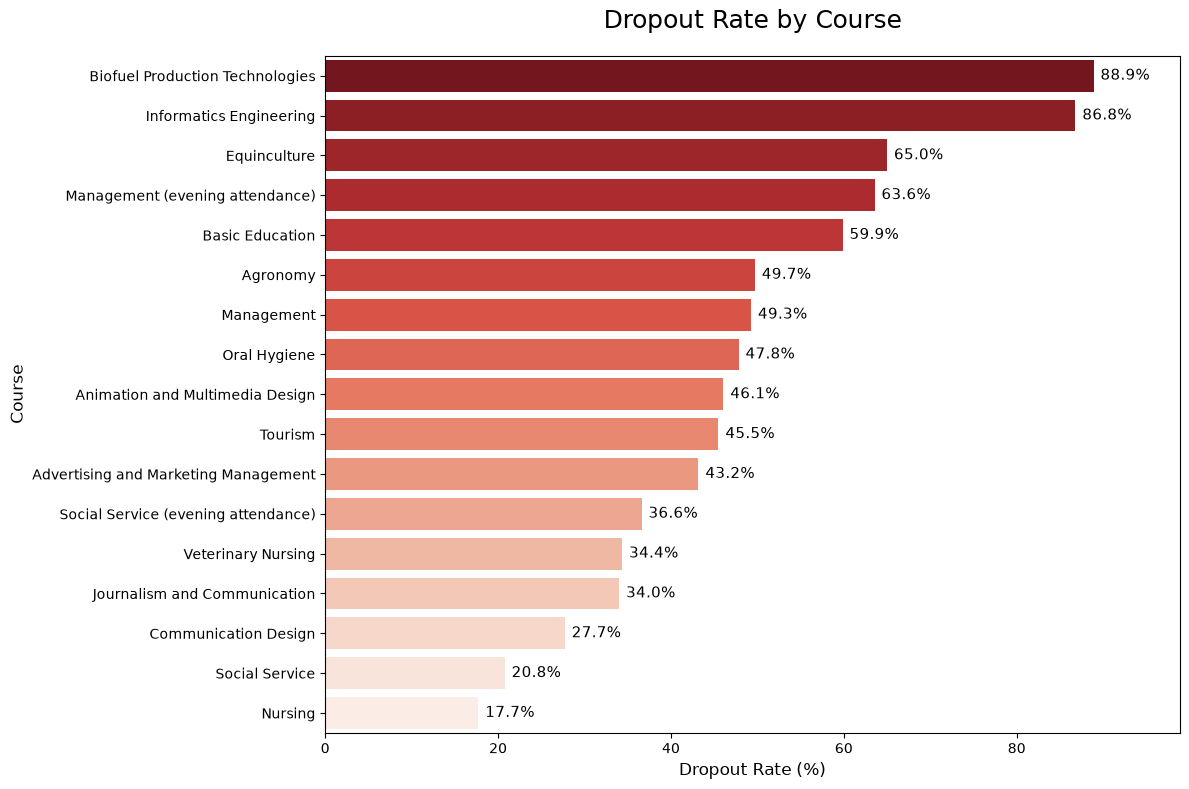

Chart successfully generated


In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 

# Filter df_visualisation to Graduate and Dropout only 
df_plot = df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])].copy()

# Calculate dropout rate per course, crosstab with normalize='index' calculates the row wise percentage
course_stats = pd.crosstab(df_plot['Course'], df_plot['Target'], normalize='index') * 100

# Extract just the 'Dropout' rates and sort highest to lowest 
dropout_rates = course_stats['Dropout'].sort_values(ascending=False)

# Set up wide figure 
plt.figure(figsize=(12, 8))

# plot horizontal bar chart 
ax = sns.barplot(
    x=dropout_rates.values,
    y=dropout_rates.index,
    hue=dropout_rates.index,
    legend=False,
    palette='Reds_r', # Red gradient emphasises the negative aspect of dropping out
    orient='h' # Horizontal, tells python to darw bars going sideways left to right
)

# Add percentage right next to the bars
for container in ax.containers:
    # We use container.datavalues to grab the exact length of the bar formatted to one decimal place 
    labels = [
        f'{val:.1f}%' 
        for val in container.datavalues
        ]
    ax.bar_label(container, labels=labels, padding=5, fontsize=11)

# Apply Titles
plt.title('Dropout Rate by Course', fontsize=18, pad=20)
plt.xlabel('Dropout Rate (%)', fontsize=12)
plt.ylabel('Course', fontsize=12)

# Give the x axis a 10% buffer so the percentage labels don't get cut off 
plt.xlim(0, dropout_rates.max() + 10)

plt.tight_layout()

plt.savefig('../outputs/figures/Dropout_Rate_By_Course.png', dpi=300, bbox_inches='tight')

plt.show()

print("Chart successfully generated")

In [45]:
# Check student counts per course
course_counts = df_plot['Course'].value_counts()
print(course_counts)

Course
Nursing                                 666
Social Service                          313
Journalism and Communication            297
Management                              272
Veterinary Nursing                      262
Advertising and Marketing Management    220
Management (evening attendance)         214
Tourism                                 211
Social Service (evening attendance)     194
Communication Design                    184
Animation and Multimedia Design         178
Agronomy                                173
Basic Education                         142
Equinculture                            120
Informatics Engineering                 106
Oral Hygiene                             69
Biofuel Production Technologies           9
Name: count, dtype: int64


Dropout rate by Course with a threshold of minimum 30 students

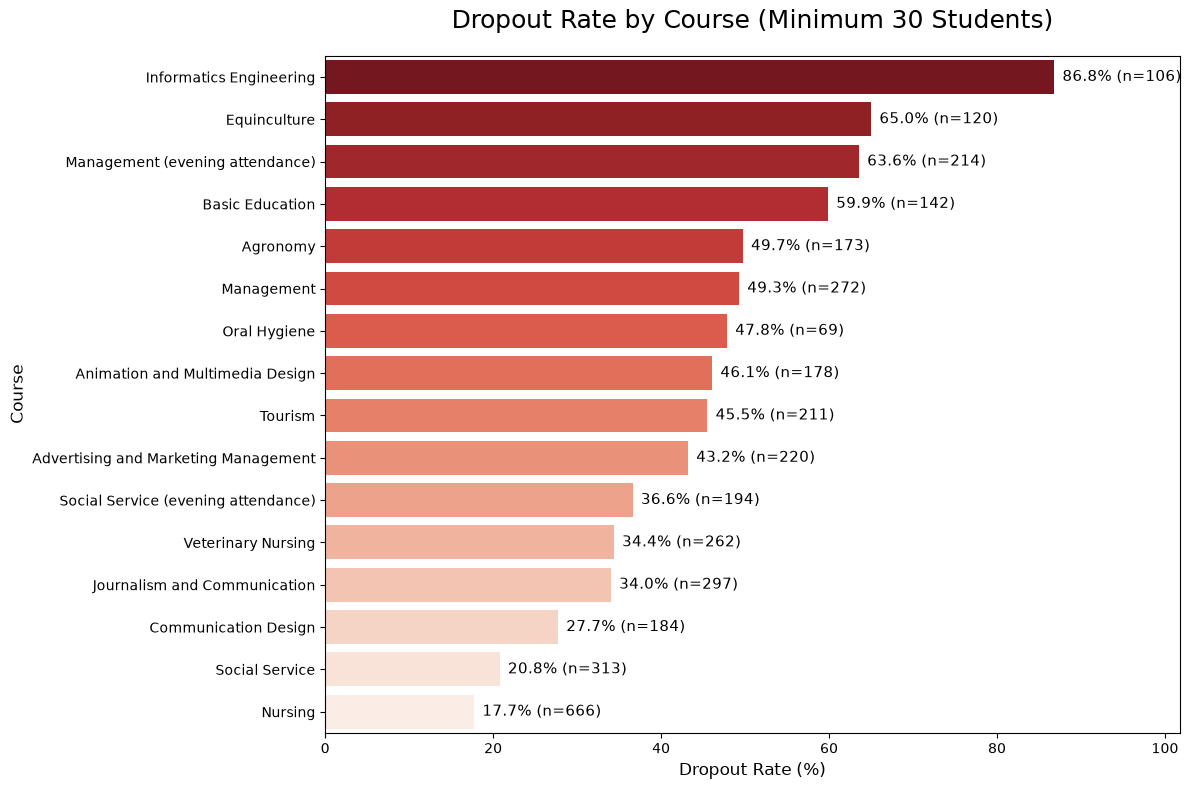

Chart successfully generated


In [47]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 

# Threshold and filter 
MIN_STUDENTS = 30
course_counts = df_plot['Course'].value_counts()
valid_courses = course_counts[course_counts >= MIN_STUDENTS].index
df_filtered = df_plot[df_plot['Course'].isin(valid_courses)].copy()

# Calculate Stats 
course_stats = pd.crosstab(df_filtered['Course'], df_filtered['Target'], normalize='index') * 100
dropout_rates = course_stats['Dropout'].sort_values(ascending=False)

# Set up wide figure 
plt.figure(figsize=(12, 8))

# plot horizontal bar chart 
ax = sns.barplot(
    x=dropout_rates.values,
    y=dropout_rates.index,
    hue=dropout_rates.index,
    legend=False,
    palette='Reds_r', # Red gradient emphasises the negative aspect of dropping out
    orient='h' # Horizontal, tells python to darw bars going sideways left to right
)
# Show dropout rate AND student count
# We will use plt.text to manually stamp the correct label on each bar 
# enumerate() gives us the row number(i), the course name (course) and the percentage (val)
for i, (course, val) in enumerate(dropout_rates.items()):
    n_students = int(course_counts[course])
    label = f'{val:.1f}% (n={n_students})'
    # Place text at X = val + 1 (just past the bar), Y = i (centered on the bar vertically)
    plt.text(val + 1, i, label, va='center', fontsize=11)

# Apply Titles
plt.title(f'Dropout Rate by Course (Minimum {MIN_STUDENTS} Students)', fontsize=18, pad=20)
plt.xlabel('Dropout Rate (%)', fontsize=12)
plt.ylabel('Course', fontsize=12)

# Give the x axis a 10% buffer so the percentage labels don't get cut off 
plt.xlim(0, dropout_rates.max() + 15)

plt.tight_layout()

plt.savefig('../outputs/figures/Dropout_Rate_By_Course_Final.png', dpi=300, bbox_inches='tight')

plt.show()

print("Chart successfully generated")

Dropout rate by Gender

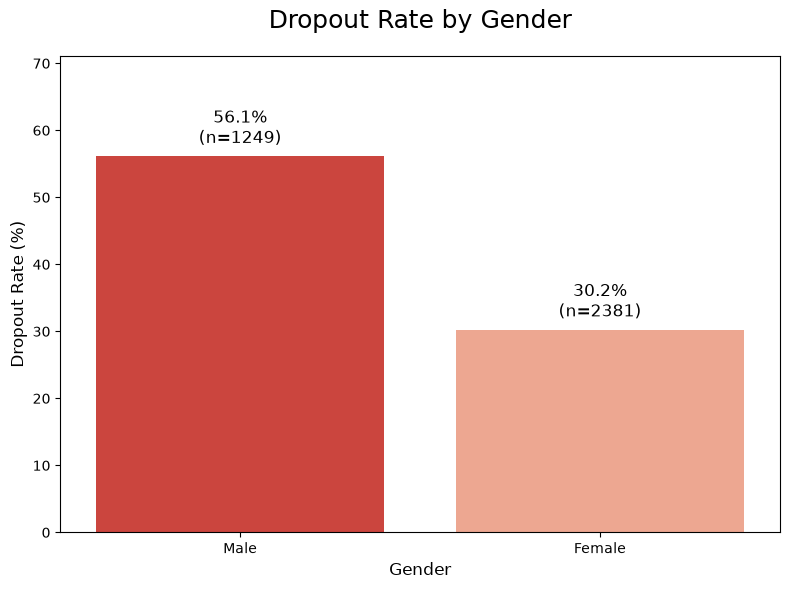

Gender demographic chart successfully generated


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter df_visualisation to Graduate and Dropout only 
df_gender = df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])].copy()

# Get total students counts per gender for our labels 
gender_counts = df_gender['Gender'].value_counts()

# Calculate dropout rate for Female vs Male
gender_stats = pd.crosstab(df_gender['Gender'], df_gender['Target'], normalize='index') * 100
dropout_rates_gender = gender_stats['Dropout'].sort_values(ascending=False)

# Set up the figure 
plt.figure(figsize=(8, 6))

# plot vertical bar chart 
ax = sns.barplot(
    x=dropout_rates_gender.index,   
    y=dropout_rates_gender.values, 
    hue=dropout_rates_gender.index,
    legend=False,
    palette='Reds_r'
)

# Add percentage labels AND sample size
for i, (gender, val) in enumerate(dropout_rates_gender.items()):
    n_students = int(gender_counts[gender])
    label = f'{val:.1f}%\n(n={n_students})'
    
    # X = i (centered over the 0 or 1 slot on the x-axis)
    # Y = val + 2 (places the text safely 2 points above the top of the bar)
    # ha='center' ensures the text is perfectly middle-aligned over the bar
    plt.text(i, val + 2, label, ha='center', fontsize=12)

# Apply Titles
plt.title('Dropout Rate by Gender', fontsize=18, pad=20)
plt.ylabel('Dropout Rate (%)', fontsize=12)
plt.xlabel('Gender', fontsize=12)

# Give the y axis a buffer at the top so the text labels don't get cut off
plt.ylim(0, dropout_rates_gender.max() + 15) 
plt.tight_layout()


plt.savefig('../outputs/figures/Dropout_Rate_By_Gender_Vertical.png', dpi=300, bbox_inches='tight')


plt.show()

print("Gender demographic chart successfully generated")

In [54]:
# Check gender breakdown per course
gender_course = pd.crosstab(
    df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])]['Course'],
    df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])]['Gender'],
    normalize='index'
) * 100

print(gender_course.round(1))

Gender                                Female  Male
Course                                            
Advertising and Marketing Management    54.5  45.5
Agronomy                                29.5  70.5
Animation and Multimedia Design         46.6  53.4
Basic Education                         95.8   4.2
Biofuel Production Technologies         22.2  77.8
Communication Design                    58.2  41.8
Equinculture                            54.2  45.8
Informatics Engineering                  5.7  94.3
Journalism and Communication            65.7  34.3
Management                              57.0  43.0
Management (evening attendance)         43.9  56.1
Nursing                                 81.2  18.8
Oral Hygiene                            76.8  23.2
Social Service                          86.3  13.7
Social Service (evening attendance)     80.9  19.1
Tourism                                 64.0  36.0
Veterinary Nursing                      80.5  19.5


Dropout rate by Scholarship Status

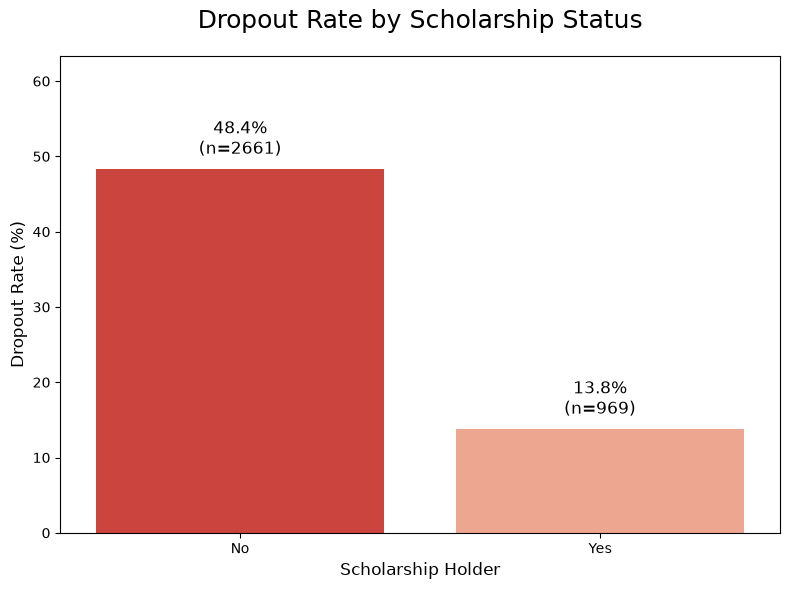

Scholarship chart successfully generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter df_visualisation to Graduate and Dropout only 
df_scholar = df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])].copy()

# Calculate dropout rate for Scholarship holders vs Non holders
scholar_stats = pd.crosstab(df_scholar['Scholarship holder'], df_scholar['Target'], normalize='index') * 100
dropout_rates_scholar = scholar_stats['Dropout'].sort_values(ascending=False)

# Set up the figure 
plt.figure(figsize=(8, 6))

# plot vertical bar chart 
ax = sns.barplot(
    x=dropout_rates_scholar.index,   
    y=dropout_rates_scholar.values,  
    hue=dropout_rates_scholar.index,
    legend=False,
    palette='Reds_r'
)

for i, (status, val) in enumerate(dropout_rates_scholar.items()):
    n_students = len(df_scholar[df_scholar['Scholarship holder'] == status])
    label = f'{val:.1f}%\n(n={n_students})'
    
    # Place text safely above the top of the bar
    plt.text(i, val + 2, label, ha='center', fontsize=12)

# Apply Titles
plt.title('Dropout Rate by Scholarship Status', fontsize=18, pad=20)
plt.ylabel('Dropout Rate (%)', fontsize=12)
plt.xlabel('Scholarship Holder', fontsize=12)

# Give the y axis a buffer at the top so the text labels don't get cut off
plt.ylim(0, dropout_rates_scholar.max() + 15) 
plt.tight_layout()



plt.savefig('../outputs/figures/Dropout_Rate_By_Scholarship.png', dpi=300, bbox_inches='tight')


plt.show()

print("Scholarship chart successfully generated.")

Dropout rate by Tuition Fees Up To Date

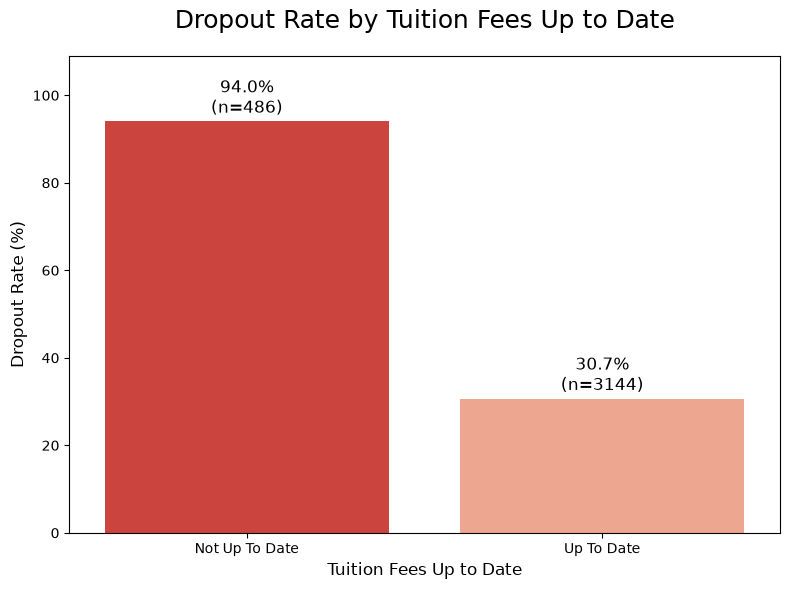

Tuition fees chart successfully generated


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter df_visualisation to Graduate and Dropout only 
df_tuition = df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])].copy()

# Calculate dropout rate for tuition fees up to date 
tuition_stats = pd.crosstab(df_tuition['Tuition fees up to date'], df_tuition['Target'], normalize='index') * 100
dropout_rates_tuition =  tuition_stats['Dropout'].sort_values(ascending=False)

# Set up figure 
plt.figure(figsize=(8, 6))

# plot vertical bar chart 
ax = sns.barplot(
    x=dropout_rates_tuition.index,   
    y=dropout_rates_tuition.values,  
    hue=dropout_rates_tuition.index,
    legend=False,
    palette='Reds_r' 
)
# Add percentage labels AND sample size
for i, (status, val) in enumerate(dropout_rates_tuition.items()):
    n_students = len(df_tuition[df_tuition['Tuition fees up to date'] == status])
    label = f'{val:.1f}%\n(n={n_students})'

    # Place text safely above the top of the bar
    plt.text(i, val + 2, label, ha='center', fontsize=12)

# Apply Titles
plt.title('Dropout Rate by Tuition Fees Up to Date', fontsize=18, pad=20)
plt.ylabel('Dropout Rate (%)', fontsize=12)
plt.xlabel('Tuition Fees Up to Date', fontsize=12)

# Give the y axis a buffer at the top so the text labels don't get cut off
plt.ylim(0, dropout_rates_tuition.max() + 15) 
plt.tight_layout()

plt.savefig('../outputs/figures/Dropout_Rate_By_Tuition.png', dpi=300, bbox_inches='tight')

plt.show()

print("Tuition fees chart successfully generated")


Dropout by Debtor

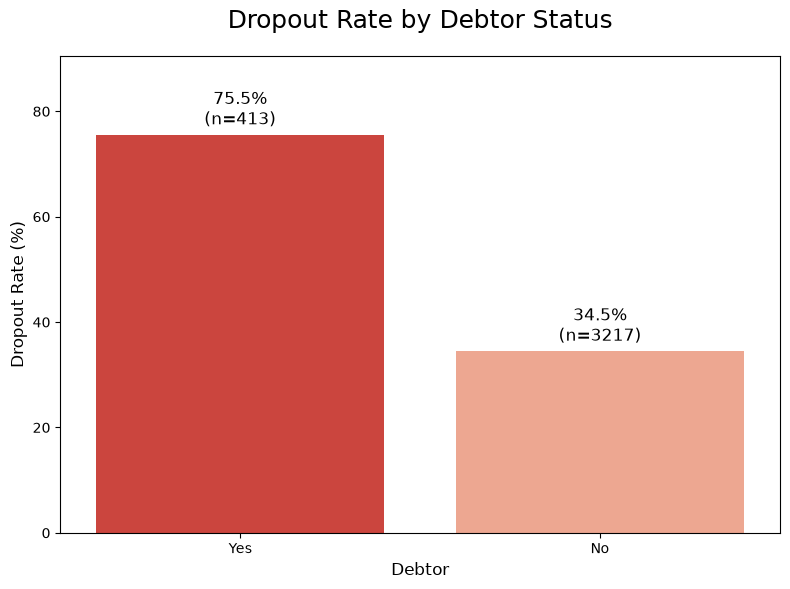

Debtor chart successfully generated


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter df_visualisation to Graduate and Dropout only 
df_debtor = df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])].copy()

# Calculate dropout rate for Debtors vs Non Debtors
debtor_stats = pd.crosstab(df_debtor['Debtor'], df_debtor['Target'], normalize='index') * 100
dropout_rates_debtor = debtor_stats['Dropout'].sort_values(ascending=False)

# Set up the figure
plt.figure(figsize=(8, 6))

# plot vertical bar chart 
ax = sns.barplot(
    x=dropout_rates_debtor.index,   
    y=dropout_rates_debtor.values,  
    hue=dropout_rates_debtor.index,
    legend=False,
    palette='Reds_r'
)
# Add percentage labels AND sample size
for i, (status, val) in enumerate(dropout_rates_debtor.items()):
    n_students = len(df_debtor[df_debtor['Debtor'] == status])
    label = f'{val:.1f}%\n(n={n_students})'

    # Place text safely above the top of the bar
    plt.text(i, val + 2, label, ha='center', fontsize=12)

# Apply Titles
plt.title('Dropout Rate by Debtor Status', fontsize=18, pad=20)
plt.ylabel('Dropout Rate (%)', fontsize=12)
plt.xlabel('Debtor', fontsize=12)

# Give the y axis a buffer at the top so the text labels don't get cut off
plt.ylim(0, dropout_rates_debtor.max() + 15) 
plt.tight_layout()

plt.savefig('../outputs/figures/Dropout_Rate_By_Debtor.png', dpi=300, bbox_inches='tight')

plt.show()

print("Debtor chart successfully generated")

Dropout by Daytime/Evening Attendance

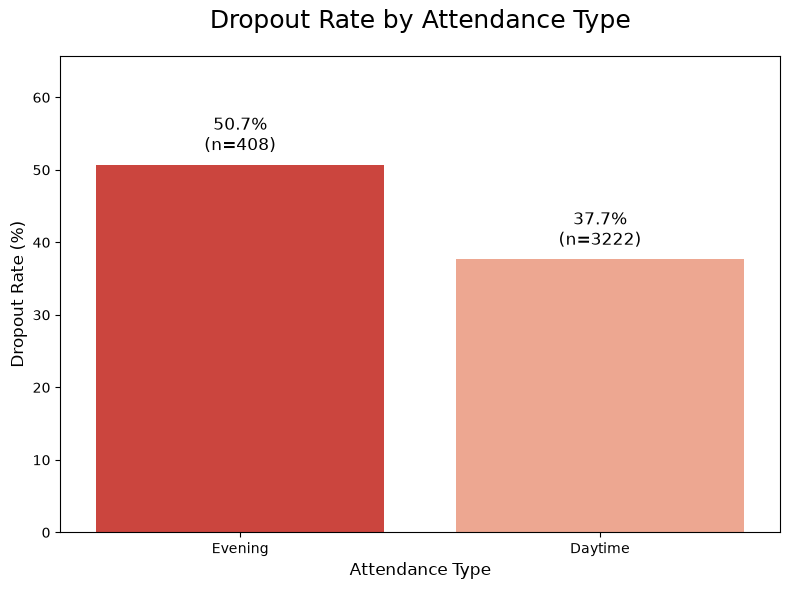

Attendance chart successfully generated


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the column name
column_name = 'Daytime/evening attendance'

# Filter df_visualisation to Graduate and Dropout only 
df_attendance = df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])].copy()

# Calculate dropout rate for Daytime vs Evening
attendance_stats = pd.crosstab(df_attendance[column_name], df_attendance['Target'], normalize='index') * 100
dropout_rates_attendance = attendance_stats['Dropout'].sort_values(ascending=False)

# Set up figure 
plt.figure(figsize=(8, 6))

# plot virtical bar chart 
ax = sns.barplot(
    x=dropout_rates_attendance.index,   
    y=dropout_rates_attendance.values,  
    hue=dropout_rates_attendance.index,
    legend=False,
    palette='Reds_r'
)
# Add percentage labels AND sample size
for i, (status, val) in enumerate(dropout_rates_attendance.items()):
    n_students = len(df_attendance[df_attendance[column_name] == status])
    label = f'{val:.1f}%\n(n={n_students})'
    
    # Place text safely above the top of the bar
    plt.text(i, val + 2, label, ha='center', fontsize=12)

# Apply Titles
plt.title('Dropout Rate by Attendance Type', fontsize=18, pad=20)
plt.ylabel('Dropout Rate (%)', fontsize=12)
plt.xlabel('Attendance Type', fontsize=12)

# Give the y axis a buffer at the top so the text labels don't get cut off
plt.ylim(0, dropout_rates_attendance.max() + 15) 
plt.tight_layout()

plt.savefig('../outputs/figures/Dropout_Rate_By_Attendance.png', dpi=300, bbox_inches='tight')

plt.show()

print("Attendance chart successfully generated")

Age distribution by outcome

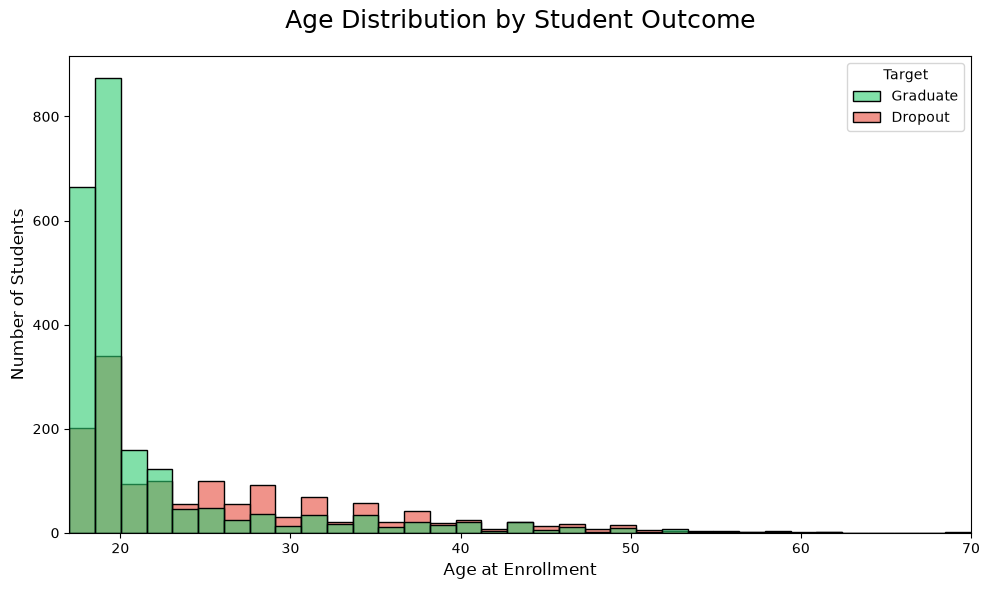

Box plot successfully generated


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter df_visualisation to Graduate and Dropout only 
df_age = df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])].copy()

# Set up figure 
plt.figure(figsize=(10, 6))

# Plot the histogram 
sns.histplot(
    data=df_age,
    x='Age at enrollment',
    hue='Target',
    hue_order=['Graduate', 'Dropout'],
    palette={'Graduate': '#2ecc71', 'Dropout': '#e74c3c'},
    bins=35,             # Breaks the ages into 35 neat columns
    kde=False,           # Keeps it as pure bars no trend line
    alpha=0.6,           # Makes the bars slightly transparent
    multiple="layer"     # Layers the bars over each other for direct comparison
)
# Apply Titles
plt.title('Age Distribution by Student Outcome', fontsize=18, pad=20)
plt.xlabel('Age at Enrollment', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

# Set the x axis limits to perfectly fit the youngest and oldest students
plt.xlim(df_age['Age at enrollment'].min(), df_age['Age at enrollment'].max())
plt.tight_layout()

plt.savefig('../outputs/figures/Age_Distribution_Histogram.png', dpi=300, bbox_inches='tight')

plt.show()

print("Box plot successfully generated")


Admission Grade distribution

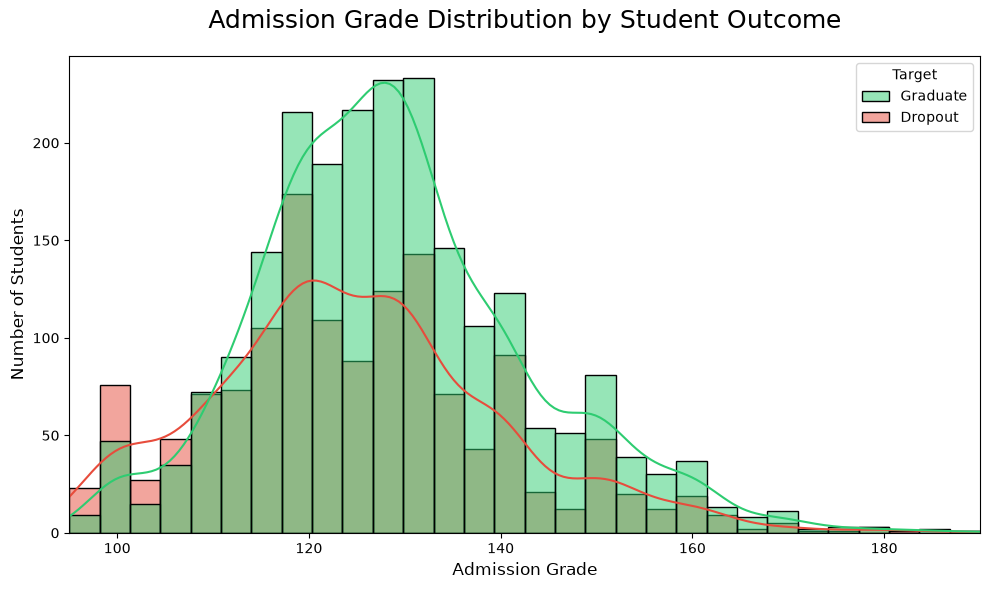

Layered histogram successfully generated


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter df_visualisation to Graduate and Dropout only 
df_admission = df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])].copy()

# Set up figure 
plt.figure(figsize=(10, 6))

# plot the layered histogram 
sns.histplot(
    data=df_admission,
    x='Admission grade',
    hue='Target',
    hue_order=['Graduate', 'Dropout'],
    palette={'Graduate': '#2ecc71', 'Dropout': '#e74c3c'},
    bins=30,             # Groups grades into 30 even buckets
    kde=True,            # Added the trend line Kernel Density Estimate to show the curve
    alpha=0.5,           # Semi transparent so we can see overlaps
    multiple="layer"     # Layers the two distributions over each other
)

# Apply Titles
plt.title('Admission Grade Distribution by Student Outcome', fontsize=18, pad=20)
plt.xlabel('Admission Grade', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

# Set x axis limits dynamically based on the actual min and max grades in the dataset
plt.xlim(df_admission['Admission grade'].min(), df_admission['Admission grade'].max())
plt.tight_layout()

plt.savefig('../outputs/figures/Admission_Grade_Histogram.png', dpi=300, bbox_inches='tight')

plt.show()

print("Layered histogram successfully generated")

Semester 1 approved distribution

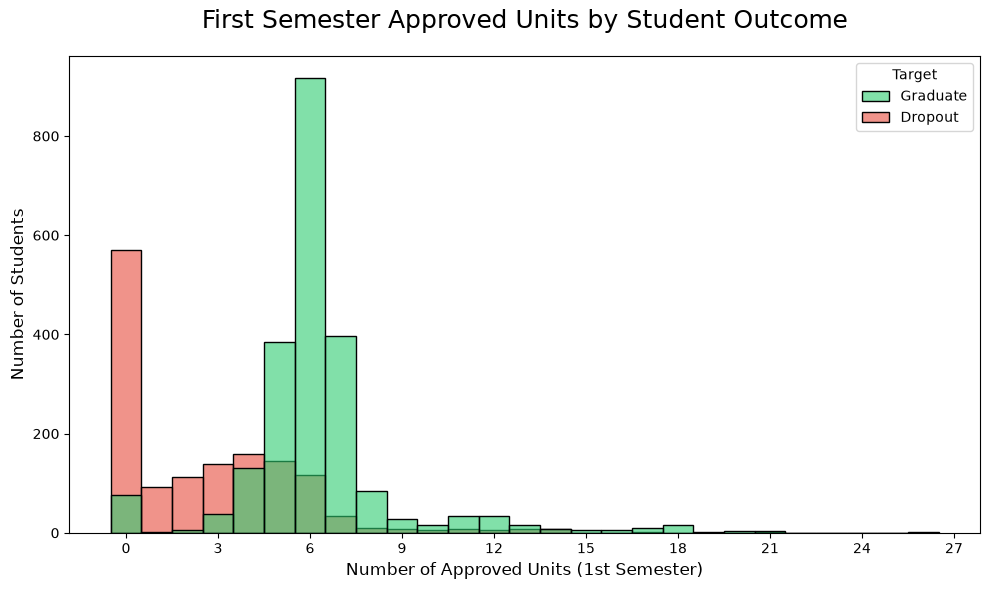

Approved units distribution successfully


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Filter df_visualisation to Graduate and Dropout only 
df_approved = df_visualisation[df_visualisation['Target'].isin(['Graduate', 'Dropout'])].copy()

# Set up figure 
plt.figure(figsize=(10, 6))

#mPlot the Histogram for discrete numbers
sns.histplot(
    data=df_approved,
    x='Curricular units 1st sem (approved)',
    hue='Target',
    hue_order=['Graduate', 'Dropout'],
    palette={'Graduate': '#2ecc71', 'Dropout': '#e74c3c'},
    discrete=True,       # Forces bars to align perfectly on whole numbers
    alpha=0.6,           
    multiple="layer"     
)

# Apply Titles
plt.title('First Semester Approved Units by Student Outcome', fontsize=18, pad=20)
plt.xlabel('Number of Approved Units (1st Semester)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

# Force the X axis to only show whole numbers
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()

plt.savefig('../outputs/figures/First_Semester_Approved_Units.png', dpi=300, bbox_inches='tight')

plt.show()

print("Approved units distribution successfully")

Descriptive Statistics by Outcome

In [17]:
# Define the subset of numerical features
numerical_cols = [
    'Age at enrollment', 
    'Previous qualification (grade)', 
    'Admission grade',
    'Unemployment rate', 
    'Inflation rate', 
    'GDP', 
    'Application order',
    'Curricular units 1st sem (credited)', 
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 
    'Curricular units 1st sem (without evaluations)'
]

# Define the exact column to look at 
target_col = 'Target'
columns_to_keep = numerical_cols + [target_col]

# Group the data, calculate Mean and Std and round it to 2 decimal places 
decs_stats = df[columns_to_keep].groupby(target_col).agg(['mean', 'std']).round(2)

# Transpose the table so features are on the left and status on top
decs_stats = decs_stats.T

decs_stats


Target                                               Dropout  Enrolled  \
Age at enrollment                              mean    26.07     22.37   
                                               std      8.70      6.30   
Previous qualification (grade)                 mean   131.11    131.21   
                                               std     12.87     12.87   
Admission grade                                mean   124.96    125.53   
                                               std     15.13     13.79   
Unemployment rate                              mean    11.62     11.27   
                                               std      2.77      2.63   
Inflation rate                                 mean     1.28      1.21   
                                               std      1.40      1.37   
GDP                                            mean    -0.15      0.05   
                                               std      2.25      2.32   
Application order                              mean     1.59      1.63   
                                               std      1.22      1.21   
Curricular units 1st sem (credited)            mean     0.61      0.51   
                                               std      2.10      1.72   
Curricular units 1st sem (enrolled)            mean     5.82      5.96   
                                               std      2.33      1.99   
Curricular units 1st sem (evaluations)         mean     7.75      9.34   
                                               std      4.92      3.46   
Curricular units 1st sem (approved)            mean     2.55      4.32   
                                               std      2.86      2.29   
Curricular units 1st sem (grade)               mean     7.26     11.13   
                                               std      6.03      3.68   
Curricular units 1st sem (without evaluations) mean     0.19      0.18   
                                               std      0.79      0.74   

Target                                               Graduate  
Age at enrollment                              mean     21.78  
                                               std       6.69  
Previous qualification (grade)                 mean    134.08  
                                               std      13.34  
Admission grade                                mean    128.79  
                                               std      14.07  
Unemployment rate                              mean     11.64  
                                               std       2.60  
Inflation rate                                 mean      1.20  
                                               std       1.37  
GDP                                            mean      0.08  
                                               std       2.26  
Application order                              mean      1.85  
                                               std       1.40  
Curricular units 1st sem (credited)            mean      0.85  
                                               std       2.69  
Curricular units 1st sem (enrolled)            mean      6.67  
                                               std       2.66  
Curricular units 1st sem (evaluations)         mean      8.28  
                                               std       3.81  
Curricular units 1st sem (approved)            mean      6.23  
                                               std       2.58  
Curricular units 1st sem (grade)               mean     12.64  
                                               std       2.70  
Curricular units 1st sem (without evaluations) mean      0.09  
                                               std       0.59